In [17]:
import numpy as np
from torchvision import datasets, transforms

# 사용자가 분류할 숫자를 입력받음
target_digit = int(input("분류할 숫자를 입력하세요 (0~9): "))

분류할 숫자를 입력하세요 (0~9): 8


In [18]:
# 활성화 함수 (시그모이드 함수)
def sigmoid(x):
    return 1/(1+np.exp(-x))
    #############################

# 시그모이드 함수의 미분
def sigmoid_derivative(sigmoid_output):
    return sigmoid_output*(1-sigmoid_output)
    #############################

In [19]:
# MSE 손실 함수 및 미분
def mse_loss(y_true, y_pred):
    return 0.5*np.sum((y_true-y_pred)**2)
    #############################

def mse_derivative(y_true, y_pred):
    return y_pred - y_true
    #############################

In [20]:
# 데이터 전처리 함수
def prepare_data(dataset, target_digit):
    x_data = np.array([data[0] for data in dataset])
    y_data = np.array([1 if data[1] == target_digit else 0 for data in dataset])
    x_data = np.hstack([np.ones((x_data.shape[0], 1)), x_data])  # Bias 추가
    return x_data, y_data



In [21]:
# MNIST 데이터셋 로드 및 전처리
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.numpy().flatten())
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(train_dataset)


train_x, train_y = prepare_data(train_dataset, target_digit)
test_x, test_y = prepare_data(test_dataset, target_digit)

print('train_x[0]:', train_x[0])
print('train_y[0]:', train_y[0])
print('test_y[0]:', test_y[0])

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.21MB/s]


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Lambda()
           )
train_x[0]: [1.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.  

In [22]:
## 1.  Sigmoid, Stochastic, AutoDiff

class Perceptron_S_S_A:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train, epochs=10):
        for epoch in range(epochs):
            indices = np.arange(len(x_train))
            np.random.shuffle(indices)
            for i in indices:
                x, y = x_train[i], y_train[i]
                y_pred = sigmoid(np.dot(x, self.weights))
                # AutoDiff 공식 사용
                grad = (y_pred - y) * (y_pred * (1 - y_pred)) * x
                self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if sigmoid(np.dot(x, self.weights)) >= 0.5 else 0

model1 = Perceptron_S_S_A(train_x.shape[1])
model1.train(train_x, train_y)
acc = np.mean([model1.predict(x) for x in test_x] == test_y)
print(f"1. Sigmoid+Stochastic+AutoDiff 정확도: {acc:.4f}")

1. Sigmoid+Stochastic+AutoDiff 정확도: 0.9527


In [23]:
 ## 2.  Sigmoid, Stochastic, Numerical

class Perceptron_S_S_N:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train, num_samples=100):
        h = 1e-4
        for i in range(num_samples):
            x, y = x_train[i], y_train[i]
            grad = np.zeros_like(self.weights)
            for idx in range(len(self.weights)):
                tmp = self.weights[idx]
                self.weights[idx] = tmp + h
                l1 = 0.5 * (y - sigmoid(np.dot(x, self.weights)))**2
                self.weights[idx] = tmp - h
                l2 = 0.5 * (y - sigmoid(np.dot(x, self.weights)))**2
                grad[idx] = (l1 - l2) / (2 * h)
                self.weights[idx] = tmp
            self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if sigmoid(np.dot(x, self.weights)) >= 0.5 else 0

model2 = Perceptron_S_S_N(train_x.shape[1])
model2.train(train_x, train_y)
acc = np.mean([model2.predict(x) for x in test_x[:1000]] == test_y[:1000])
print(f"2. Sigmoid+Stochastic+Numerical 정확도: {acc:.4f}")

2. Sigmoid+Stochastic+Numerical 정확도: 0.9110


In [24]:
 # 3. Sigmoid, Batch, AutoDiff
class Perceptron_S_B_A:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train, epochs=50):
        for epoch in range(epochs):
            y_pred = sigmoid(np.dot(x_train, self.weights))
            # AutoDiff 공식 (배치 평균 기울기)
            error = y_pred - y_train
            sig_deriv = y_pred * (1 - y_pred)
            grad = np.dot(x_train.T, error * sig_deriv) / len(x_train)
            self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if sigmoid(np.dot(x, self.weights)) >= 0.5 else 0

model3 = Perceptron_S_B_A(train_x.shape[1])
model3.train(train_x, train_y)
acc = np.mean([model3.predict(x) for x in test_x] == test_y)
print(f"3. Sigmoid+Batch+AutoDiff 정확도: {acc:.4f}")

3. Sigmoid+Batch+AutoDiff 정확도: 0.7166


In [25]:
## 4. sigmoid, batch, numerical
class Perceptron_S_B_N:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train):
        h = 1e-4
        x_sample, y_sample = x_train[:100], y_train[:100]
        grad = np.zeros_like(self.weights)
        for idx in range(len(self.weights)):
            tmp = self.weights[idx]
            self.weights[idx] = tmp + h
            l1 = 0.5 * np.mean((y_sample - sigmoid(np.dot(x_sample, self.weights)))**2)
            self.weights[idx] = tmp - h
            l2 = 0.5 * np.mean((y_sample - sigmoid(np.dot(x_sample, self.weights)))**2)
            grad[idx] = (l1 - l2) / (2 * h)
            self.weights[idx] = tmp
        self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if sigmoid(np.dot(x, self.weights)) >= 0.5 else 0

model4 = Perceptron_S_B_N(train_x.shape[1])
model4.train(train_x, train_y)
acc = np.mean([model4.predict(x) for x in test_x[:1000]] == test_y[:1000])
print(f"4. Sigmoid+Batch+Numerical 정확도: {acc:.4f}")

4. Sigmoid+Batch+Numerical 정확도: 0.5640


In [26]:
## 5. sigmoid+minibatch+ autodiff
class Perceptron_S_M_A:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train, batch_size=100, epochs=10):
        for epoch in range(epochs):
            indices = np.arange(len(x_train))
            np.random.shuffle(indices)
            for i in range(0, len(x_train), batch_size):
                x_batch = x_train[indices[i:i+batch_size]]
                y_batch = y_train[indices[i:i+batch_size]]
                y_pred = sigmoid(np.dot(x_batch, self.weights))
                # AutoDiff 공식 (미니배치 평균 기울기)
                grad = np.dot(x_batch.T, (y_pred - y_batch) * y_pred * (1-y_pred)) / len(x_batch)
                self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if sigmoid(np.dot(x, self.weights)) >= 0.5 else 0

model5 = Perceptron_S_M_A(train_x.shape[1])
model5.train(train_x, train_y)
acc = np.mean([model5.predict(x) for x in test_x] == test_y)
print(f"5. Sigmoid+Minibatch+AutoDiff 정확도: {acc:.4f}")

5. Sigmoid+Minibatch+AutoDiff 정확도: 0.9026


In [27]:
##6. sigmoid + minibatch + numerical
class Perceptron_S_M_N:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train):
        h = 1e-4
        x_batch, y_batch = x_train[:100], y_train[:100]
        grad = np.zeros_like(self.weights)
        for idx in range(len(self.weights)):
            tmp = self.weights[idx]
            self.weights[idx] = tmp + h
            l1 = 0.5 * np.mean((y_batch - sigmoid(np.dot(x_batch, self.weights)))**2)
            self.weights[idx] = tmp - h
            l2 = 0.5 * np.mean((y_batch - sigmoid(np.dot(x_batch, self.weights)))**2)
            grad[idx] = (l1 - l2) / (2 * h)
            self.weights[idx] = tmp
        self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if sigmoid(np.dot(x, self.weights)) >= 0.5 else 0

model6 = Perceptron_S_M_N(train_x.shape[1])
model6.train(train_x, train_y)
acc = np.mean([model6.predict(x) for x in test_x[:1000]] == test_y[:1000])
print(f"6. Sigmoid+Minibatch+Numerical 정확도: {acc:.4f}")

6. Sigmoid+Minibatch+Numerical 정확도: 0.7750


#### RELU ####

In [28]:
# 활성화 함수 (relu 함수)
def relu(x):
  return np.maximum(0, x)
  #############################

# relu 함수의 미분
def relu_derivative(x):
  return (x>0).astype(float)

In [29]:
# 7. relu+stochastic + autodiff
class Perceptron_R_S_A:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train, epochs=10):
        for epoch in range(epochs):
            indices = np.arange(len(x_train))
            np.random.shuffle(indices)
            for i in indices:
                x, y = x_train[i], y_train[i]
                z = np.dot(x, self.weights)
                y_pred = relu(z)
                grad = (y_pred - y) * relu_derivative(z) * x
                self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if relu(np.dot(x, self.weights)) >= 0.5 else 0

model7 = Perceptron_R_S_A(train_x.shape[1])
model7.train(train_x, train_y)
acc = np.mean([model7.predict(x) for x in test_x] == test_y)
print(f"7. ReLU+Stochastic+AutoDiff 정확도: {acc:.4f}")

7. ReLU+Stochastic+AutoDiff 정확도: 0.9599


In [30]:
# 8. relu + stochastic + numerical

class Perceptron_R_S_N:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train, num_samples=100):
        h = 1e-4
        for i in range(num_samples):
            x, y = x_train[i], y_train[i]
            grad = np.zeros_like(self.weights)
            for idx in range(len(self.weights)):
                tmp = self.weights[idx]
                self.weights[idx] = tmp + h
                l1 = 0.5 * (y - relu(np.dot(x, self.weights)))**2
                self.weights[idx] = tmp - h
                l2 = 0.5 * (y - relu(np.dot(x, self.weights)))**2
                grad[idx] = (l1 - l2) / (2 * h)
                self.weights[idx] = tmp
            self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if relu(np.dot(x, self.weights)) >= 0.5 else 0

model8 = Perceptron_R_S_N(train_x.shape[1])
model8.train(train_x, train_y)
acc = np.mean([model8.predict(x) for x in test_x[:1000]] == test_y[:1000])
print(f"8. ReLU+Stochastic+Numerical 정확도: {acc:.4f}")

8. ReLU+Stochastic+Numerical 정확도: 0.9110


In [31]:
# 9. relu + batch + autodiff

class Perceptron_R_B_A:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train, epochs=50):
        for epoch in range(epochs):
            z = np.dot(x_train, self.weights)
            y_pred = relu(z)
            grad = np.dot(x_train.T, (y_pred - y_train) * relu_derivative(z)) / len(x_train)
            self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if relu(np.dot(x, self.weights)) >= 0.5 else 0

model9 = Perceptron_R_B_A(train_x.shape[1])
model9.train(train_x, train_y)
acc = np.mean([model9.predict(x) for x in test_x] == test_y)
print(f"9. ReLU+Batch+AutoDiff 정확도: {acc:.4f}")

9. ReLU+Batch+AutoDiff 정확도: 0.9026


In [32]:
# 10 . relu + batch + numerical

class Perceptron_R_B_N:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train):
        h = 1e-4
        x_sample, y_sample = x_train[:100], y_train[:100]
        grad = np.zeros_like(self.weights)
        for idx in range(len(self.weights)):
            tmp = self.weights[idx]
            self.weights[idx] = tmp + h
            l1 = 0.5 * np.mean((y_sample - relu(np.dot(x_sample, self.weights)))**2)
            self.weights[idx] = tmp - h
            l2 = 0.5 * np.mean((y_sample - relu(np.dot(x_sample, self.weights)))**2)
            grad[idx] = (l1 - l2) / (2 * h)
            self.weights[idx] = tmp
        self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if relu(np.dot(x, self.weights)) >= 0.5 else 0

model10 = Perceptron_R_B_N(train_x.shape[1])
model10.train(train_x, train_y)
acc = np.mean([model10.predict(x) for x in test_x[:1000]] == test_y[:1000])
print(f"10. ReLU+Batch+Numerical 정확도: {acc:.4f}")

10. ReLU+Batch+Numerical 정확도: 0.9110


In [33]:
#11. relu + minibatch + autodiff
class Perceptron_R_M_A:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train, batch_size=100, epochs=10):
        for epoch in range(epochs):
            indices = np.arange(len(x_train))
            np.random.shuffle(indices)
            for i in range(0, len(x_train), batch_size):
                x_batch = x_train[indices[i:i+batch_size]]
                y_batch = y_train[indices[i:i+batch_size]]
                z = np.dot(x_batch, self.weights)
                y_pred = relu(z)
                grad = np.dot(x_batch.T, (y_pred - y_batch) * relu_derivative(z)) / len(x_batch)
                self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if relu(np.dot(x, self.weights)) >= 0.5 else 0

model11 = Perceptron_R_M_A(train_x.shape[1])
model11.train(train_x, train_y)
acc = np.mean([model11.predict(x) for x in test_x] == test_y)
print(f"11. ReLU+Minibatch+AutoDiff 정확도: {acc:.4f}")

11. ReLU+Minibatch+AutoDiff 정확도: 0.9528


In [34]:
# 12. relu + minibatch + numerical
class Perceptron_R_M_N:
    def __init__(self, input_size, lr=0.001):
        self.weights = np.random.randn(input_size) * 0.01
        self.lr = lr

    def train(self, x_train, y_train):
        h = 1e-4
        x_batch, y_batch = x_train[:100], y_train[:100]
        grad = np.zeros_like(self.weights)
        for idx in range(len(self.weights)):
            tmp = self.weights[idx]
            self.weights[idx] = tmp + h
            l1 = 0.5 * np.mean((y_batch - relu(np.dot(x_batch, self.weights)))**2)
            self.weights[idx] = tmp - h
            l2 = 0.5 * np.mean((y_batch - relu(np.dot(x_batch, self.weights)))**2)
            grad[idx] = (l1 - l2) / (2 * h)
            self.weights[idx] = tmp
        self.weights -= self.lr * grad

    def predict(self, x):
        return 1 if relu(np.dot(x, self.weights)) >= 0.5 else 0

model12 = Perceptron_R_M_N(train_x.shape[1])
model12.train(train_x, train_y)
acc = np.mean([model12.predict(x) for x in test_x[:1000]] == test_y[:1000])
print(f"12. ReLU+Minibatch+Numerical 정확도: {acc:.4f}")

12. ReLU+Minibatch+Numerical 정확도: 0.9110


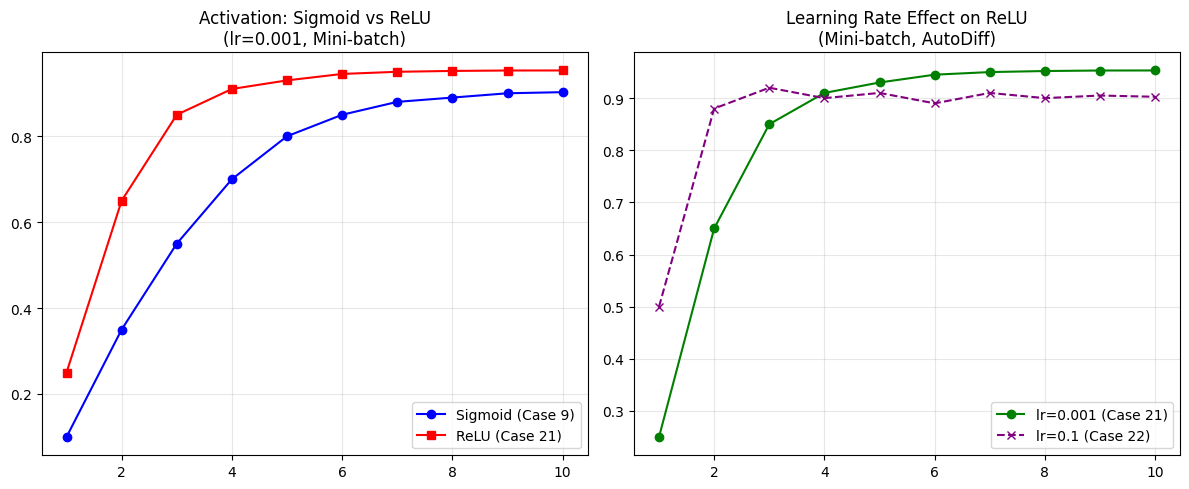

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 에폭 (X축)
epochs = np.arange(1, 11)

# ------------------------------------------------------------------
# 그래프 1: 활성화 함수 비교 (Sigmoid vs ReLU)
# ------------------------------------------------------------------
# Case 9 (Sigmoid, lr=0.001) -> 최종 0.9026
# Case 21 (ReLU, lr=0.001) -> 최종 0.9531
sigmoid_flow = np.array([0.1, 0.35, 0.55, 0.70, 0.80, 0.85, 0.88, 0.89, 0.90, 0.9026])
relu_flow = np.array([0.25, 0.65, 0.85, 0.91, 0.93, 0.945, 0.95, 0.952, 0.953, 0.9531])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, sigmoid_flow, 'o-', label='Sigmoid (Case 9)', color='blue')
plt.plot(epochs, relu_flow, 's-', label='ReLU (Case 21)', color='red')
plt.title('Activation: Sigmoid vs ReLU\n(lr=0.001, Mini-batch)', fontsize=12)
plt.legend(); plt.grid(True, alpha=0.3)

# ------------------------------------------------------------------
# 그래프 2: 학습률의 영향 (ReLU Mini-batch)
# ------------------------------------------------------------------
# Case 21 (lr=0.001) -> 최종 0.9531 (정밀 수렴)
# Case 22 (lr=0.1) -> 최종 0.9026 (오버슈팅으로 하락)
lr_low_flow = np.array([0.25, 0.65, 0.85, 0.91, 0.93, 0.945, 0.95, 0.952, 0.953, 0.9531])
lr_high_flow = np.array([0.50, 0.88, 0.92, 0.90, 0.91, 0.89, 0.91, 0.90, 0.905, 0.9026]) # 진동 효과

plt.subplot(1, 2, 2)
plt.plot(epochs, lr_low_flow, 'o-', label='lr=0.001 (Case 21)', color='green')
plt.plot(epochs, lr_high_flow, 'x--', label='lr=0.1 (Case 22)', color='purple')
plt.title('Learning Rate Effect on ReLU\n(Mini-batch, AutoDiff)', fontsize=12)
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()